# Building Encoder Decoder from Scratch

# Import Libraries

In [326]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [327]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Input, LSTM, GRU, Embedding, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import plot_model

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

print(f'Tensorflow Version: {tf.__version__}')

Tensorflow Version: 2.19.0


# Data Loading...

In [328]:
train_pairs = [
    ("hello", "হ্যালো"),
    ("how are you?", "তুমি কেমন আছো?"),
    ("i am fine", "আমি ভালো আছি"),
    ("thank you", "ধন্যবাদ"),
    ("what is your name?", "তোমার নাম কি?"),
    ("my name is john", "আমার নাম জন"),
    ("i love you", "আমি তোমাকে ভালোবাসি"),
    ("where do you live?", "তুমি কোথায় থাকো?"),
    ("i live in dhaka", "আমি ঢাকায় থাকি"),
    ("please help me", "দয়া করে আমাকে সাহায্য করো"),
    ("good morning", "সুপ্রভাত"),
    ("good night", "শুভ রাত্রি"),
    ("see you later", "পরে দেখা হবে"),
    ("i am hungry", "আমি ক্ষুধার্ত"),
    ("this is my book", "এটি আমার বই"),
    ("that is your pen", "ওটা তোমার কলম"),
    ("i like mangoes", "আমি আম পছন্দ করি"),
    ("he is my friend", "সে আমার বন্ধু"),
    ("what are you doing?", "তুমি কি করছো?"),
    ("i am studying", "আমি পড়ছি"),
    # Additional pairs
    ("i am tired", "আমি ক্লান্ত"),
    ("can you help me?", "তুমি কি আমাকে সাহায্য করতে পারবে?"),
    ("where is the bathroom?", "বাথরুম কোথায়?"),
    ("i need water", "আমার পানি দরকার"),
    ("i am happy", "আমি খুশি"),
    ("she is beautiful", "সে সুন্দর"),
    ("he is tall", "সে লম্বা"),
    ("i want to eat", "আমি খেতে চাই"),
    ("let's go", "চলো যাই"),
    ("i am sorry", "আমি দুঃখিত"),
    ("what time is it?", "কতটা বাজে?"),
    ("i don't understand", "আমি বুঝতে পারছি না"),
    ("congratulations", "অভিনন্দন"),
    ("i am cold", "আমার ঠান্ডা লাগছে"),
    ("i am hot", "আমার গরম লাগছে"),
    ("do you speak english?", "তুমি কি ইংরেজি বলতে পারো?"),
    ("i need a doctor", "আমার একজন ডাক্তারের প্রয়োজন"),
    ("call the police", "পুলিশকে ডাকো"),
    ("i am lost", "আমি হারিয়ে গেছি"),
    ("watch out!", "সাবধান!"),
    ("i am busy", "আমি ব্যস্ত"),
    ("good afternoon", "শুভ অপরাহ্ন"),
    ("good evening", "শুভ সন্ধ্যা"),
]


test_pairs = [
    ("where are you going?", "তুমি কোথায় যাচ্ছো?"),
    ("i am coming soon", "আমি শীঘ্রই আসছি"),
    ("do you understand?", "তুমি কি বুঝেছো?"),
    ("i don't know", "আমি জানি না"),
    ("can you speak english?", "তুমি কি ইংরেজি বলতে পারো?"),
]


# Preprocessing

## Step 1: Extract `Input`, `Target`

In [329]:
input_texts = [p[0] for p in train_pairs]
target_texts = ["<start> " + p[1] + " <end>" for p in train_pairs]

In [330]:
print(f'Total Input: {len(input_texts)}')
input_texts[:3]

Total Input: 43


['hello', 'how are you?', 'i am fine']

In [331]:
print(f'Total Target: {len(target_texts)}')
target_texts[:3]

Total Target: 43


['<start> হ্যালো <end>',
 '<start> তুমি কেমন আছো? <end>',
 '<start> আমি ভালো আছি <end>']

## Step 2: Build vocabularies

In [332]:
enc_tokenizer = Tokenizer()
dec_tokenizer = Tokenizer()

enc_tokenizer.fit_on_texts(input_texts)
dec_tokenizer.fit_on_texts(target_texts)

encoder_vocab = len(enc_tokenizer.word_index) + 1
decoder_vocab = len(dec_tokenizer.word_index) + 1

## Step 3: Convert texts → sequences

In [333]:
encoder_seqs = enc_tokenizer.texts_to_sequences(input_texts)
decoder_seqs = dec_tokenizer.texts_to_sequences(target_texts)

encoder_seqs[:3], decoder_seqs[:3]

([[19], [20, 8, 4], [1, 2, 21]],
 [[1, 15, 2], [1, 5, 16, 17, 2], [1, 3, 18, 19, 2]])

## Step 4. Padding

In [334]:
encoder_vocab, decoder_vocab

(75, 82)

In [335]:
# Max Input Length [I love Python] -> 3 for encoder
max_encoder_len = max([len(s) for s in encoder_seqs])
max_encoder_len

4

In [336]:
# Max Input Length [Ami Python Bhalobasi] -> 3 for decoder
max_decoder_len = max([len(s) for s in decoder_seqs])
max_decoder_len

8

In [337]:
encoder_input_data = pad_sequences(encoder_seqs, maxlen=max_encoder_len, padding='post')
decoder_input_data = pad_sequences(decoder_seqs, maxlen=max_decoder_len, padding='post')

In [338]:
encoder_input_data[0], decoder_input_data[0]

(array([19,  0,  0,  0], dtype=int32),
 array([ 1, 15,  2,  0,  0,  0,  0,  0], dtype=int32))

## Step 5: Create decoder target sequences

In [339]:
decoder_target_data = np.zeros_like(decoder_input_data)

decoder_target_data[:, :-1] = decoder_input_data[:, 1:]
decoder_target_data[:, -1] = 0   # padding for last token

# `LSTM` Encoder

Task: *Translate* from *English* -> *French*

In [340]:
latent_dim = 1024
latent_dim

1024

In [341]:

# 1000 unique English tokens.
encoder_vocab2 = 1000

# 1000 unique French tokens.
decoder_vocab2 = 1000

# This is the size of the LSTM hidden state (hidden state vector size).
latent_dim2 = 256

# Maximum number of tokens in an input sentence. [After Padding]
max_encoder_len2 = 20

# Maximum number of tokens in the output sentence.
max_decoder_len2 = 20

In [342]:
# 1. Input
encoder_input = Input(shape=(None,))

# 2. Embedding
encoder_emb = Embedding(input_dim=encoder_vocab, output_dim=latent_dim//2)(encoder_input)

# 3. LSTM
encoder_lstm_layer = LSTM(latent_dim, return_state=True)
encoder_outputs, state_h, state_c = encoder_lstm_layer(encoder_emb)

# 4. Encoder States
encoder_states = [state_h, state_c]

# `LSTM` Decoder Model (Training Mode)

In [343]:
# 1. Decoder Input
decoder_input = Input(shape=(None,))

# 2. Embeddings
decoder_emb = Embedding(input_dim=decoder_vocab, output_dim=latent_dim//2)(decoder_input)

# 3. Decoder LSTM
# Changed from Bidirectional to a single unidirectional LSTM to match encoder states and output unpacking
decoder_lstm_layer = LSTM(latent_dim, return_sequences=True, return_state=True)

decoder_outputs, _, _ = decoder_lstm_layer(decoder_emb, initial_state=encoder_states)

# 5. Dense
decoder_dense = Dense(decoder_vocab, activation='softmax')
decoder_outputs = decoder_dense(decoder_outputs)

# Full `LSTM` Seq2Seq Model

In [344]:
model = Model(inputs=[encoder_input, decoder_input], outputs=decoder_outputs)
model.summary()

Model: "functional_28"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_43      │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_44      │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_30        │ (None, None, 512) │     38,400 │ input_layer_43[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_31        │ (None, None, 512) │     41,984 │ input_layer_44[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_28 (LSTM)      │ [(None, 1024),    │  6,295,552 │ embedding_30[0][… │
│                     │ (None, 1024),     │            │                   │
│                     │ (None, 1024)]     │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_29 (LSTM)      │ [(None, None,     │  6,295,552 │ embedding_31[0][… │
│                     │ 1024), (None,     │            │ lstm_28[0][1],    │
│                     │ 1024), (None,     │            │ lstm_28[0][2]     │
│                     │ 1024)]            │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, None, 82)  │     84,050 │ lstm_29[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 12,755,538 (48.66 MB)

 Trainable params: 12,755,538 (48.66 MB)

 Non-trainable params: 0 (0.00 B)

## Plot Model

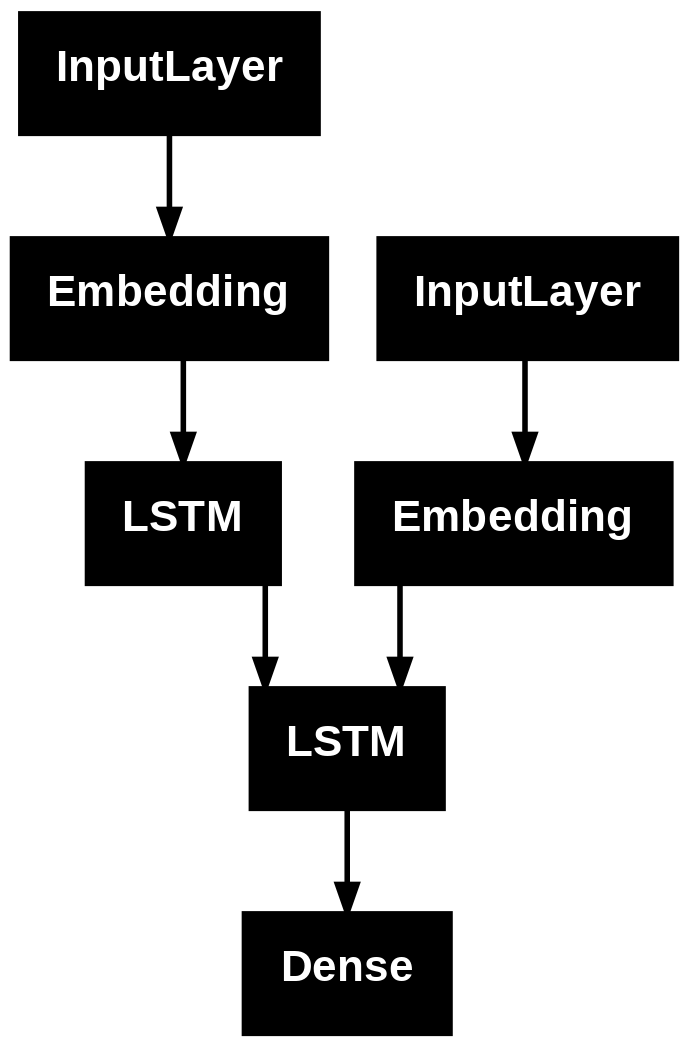

In [345]:
plot_model(model)

## Model Training

In [346]:
model.compile(
    optimizer=Adam(0.01),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [347]:
history = model.fit(
    [encoder_input_data, decoder_input_data],
    decoder_target_data,
    batch_size=4,
    epochs=50,
    validation_data=([encoder_input_data, decoder_input_data], decoder_target_data)
)

Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.3816 - loss: 4.6304 - val_accuracy: 0.6453 - val_loss: 1.9502
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 976ms/step - accuracy: 0.6413 - loss: 2.0341 - val_accuracy: 0.7035 - val_loss: 1.7245
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 857ms/step - accuracy: 0.7144 - loss: 1.4983 - val_accuracy: 0.7297 - val_loss: 1.0819
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 938ms/step - accuracy: 0.6941 - loss: 1.2014 - val_accuracy: 0.7878 - val_loss: 0.7260
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 972ms/step - accuracy: 0.7452 - loss: 0.8284 - val_accuracy: 0.8256 - val_loss: 0.5870
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 879ms/step - accuracy: 0.8442 - loss: 0.5729 - val_accuracy: 0.8808 - val_loss: 0.4123
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 927ms/step - accuracy: 0.8568 - loss: 0.4667 - val_accuracy: 0.8866 - val_loss: 0.3930
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 978ms/step - accuracy: 0.8825 - loss: 0.3900 - val_accurac

# Plot Accuracy

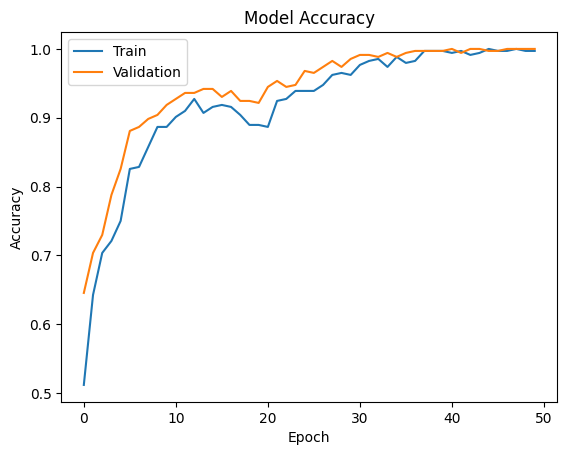

In [348]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Predictions

## Step 1: Encoder inference model

In [349]:
# Input: encoder sequence
# Output: encoder states
encoder_model = Model(encoder_input, encoder_states)

## Step 2: Decoder inference model

In [350]:
# Decoder inputs for prediction
decoder_state_input_h = Input(shape=(latent_dim,))
decoder_state_input_c = Input(shape=(latent_dim,))
decoder_states_inputs = [decoder_state_input_h, decoder_state_input_c]

# Get embeddings for decoder input
dec_emb2 = Embedding(input_dim=decoder_vocab, output_dim=latent_dim//2)(decoder_input) # Recreate embedding layer

# LSTM step
decoder_outputs2, state_h2, state_c2 = decoder_lstm_layer(
    dec_emb2, initial_state=decoder_states_inputs
)

decoder_states2 = [state_h2, state_c2]
decoder_outputs2 = decoder_dense(decoder_outputs2)

# Inference model
decoder_model = Model(
    [decoder_input] + decoder_states_inputs,
    [decoder_outputs2] + decoder_states2
)

## Step 3: Token-index mappings

In [351]:
# English tokenizer → index
input_token_index = enc_tokenizer.word_index

# Bangla tokenizer → index and reverse mapping
target_token_index = dec_tokenizer.word_index
reverse_target_word_index = {i: w for w, i in target_token_index.items()}

## Step 4: Prediction function

In [352]:
def translate_sentence(input_text):
    # 1️⃣ Tokenize and pad input
    input_seq = enc_tokenizer.texts_to_sequences([input_text])
    input_seq = pad_sequences(input_seq, maxlen=max_encoder_len, padding='post')

    # 2️⃣ Encode input sentence
    states_value = encoder_model.predict(input_seq)

    # 3️⃣ Initialize decoder input with <start> token
    target_seq = np.array([[target_token_index['start']]])
    decoded_sentence = ''
    stop_condition = False

    while not stop_condition:
        output_tokens, h, c = decoder_model.predict([target_seq] + states_value)

        # 4️⃣ Sample token with highest probability
        sampled_token_index = np.argmax(output_tokens[0, -1, :])
        sampled_word = reverse_target_word_index.get(sampled_token_index, '')

        if sampled_word == 'end' or len(decoded_sentence.split()) > max_decoder_len:
            stop_condition = True
        else:
            decoded_sentence += sampled_word + ' '

        # 5️⃣ Update target sequence & states
        target_seq = np.array([[sampled_token_index]])
        states_value = [h, c]

    return decoded_sentence.strip()

## Step 5: Translate

In [359]:
english_sentence = "i love you"
bangla_translation = translate_sentence(english_sentence)

print("English:", english_sentence)
print("Bangla:", bangla_translation)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
English: i love you
Bangla: আমি তোমাকে গেছি
